In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

plt.style.use('default')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

**Chargement de Données**

In [15]:
url = "https://cedric.cnam.fr/~crucianm/src/mammals.csv"
df = pd.read_csv(url, sep=';')
print("+"*70)
print("Données sur le sommeil des mammiferes")
print(f"\nDimension: {df.shape}")
print(f"\nNombre de variables: {df.shape[1]}")
print(f"\nNombre d'observations: {df.shape[0]}")
print("+"*70, "\n")
print(df.head())
print(df.columns.to_list())

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Données sur le sommeil des mammiferes

Dimension: (62, 11)

Nombre de variables: 11

Nombre d'observations: 62
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++ 

                     Species     BodyW  BrainW   SWS   PS    TS  LifeSpan  \
0         African elephant    6654.000  5712.0  8.35  1.8   3.3      38.6   
1  African giant pouched rat     1.000     6.6  6.30  2.0   8.3       4.5   
2               Arctic Fox       3.385    44.5  8.35  1.8  12.5      14.0   
3    Arctic ground squirrel      0.920     5.7  8.35  1.8  16.5      15.1   
4           Asian elephant    2547.000  4603.0  2.10  1.8   3.9      69.0   

      GT  PI  SEI  ODI  
0  645.0   3    5    3  
1   42.0   3    1    3  
2   60.0   1    1    1  
3   25.0   5    2    3  
4  624.0   3    5    4  
['Species', 'BodyW', 'BrainW', 'SWS', 'PS', 'TS', 'LifeSpan', 'GT', 'PI', 'SEI', 'ODI']


**Identification des variables et Nettoyage**

In [17]:
print("""
--------- description des variables --------
• Species : Nom de l'espèce (texte)
• BodyW : Poids du corps (kg)
• BrainW : Poids du cerveau (g)
• SWS : Sommeil lent (heures/jour) - "slow wave sleep"
• PS : Sommeil paradoxal (heures/jour) - "paradoxical sleep"
• TS : Sommeil total (heures/jour)
• LifeSpan : Espérance de vie (années)
• GT : Durée de gestation (jours)
• PI : Indice de prédation (1-5)
• SEI : Indice d'exposition au sommeil (1-5)
• ODI : Indice de danger global (1-5)
""")
colonnes_num = ['BodyW', 'BrainW', 'SWS', 'PS', 'TS', 'LifeSpan', 'GT', 'PI', 'SEI', 'ODI']
X = df[colonnes_num].copy()
print(f"--> Les valeurs manquantes : {X.isnull().sum()}")
X_clean = X.dropna()
print(f"--> Aprés suppression des NA : {X_clean.shape[0]}")
print(f"--> Variables Supprimés : {X.shape[0] - X_clean.shape[0]}")


--------- description des variables --------
• Species : Nom de l'espèce (texte)
• BodyW : Poids du corps (kg)
• BrainW : Poids du cerveau (g)
• SWS : Sommeil lent (heures/jour) - "slow wave sleep"
• PS : Sommeil paradoxal (heures/jour) - "paradoxical sleep"
• TS : Sommeil total (heures/jour)
• LifeSpan : Espérance de vie (années)
• GT : Durée de gestation (jours)
• PI : Indice de prédation (1-5)
• SEI : Indice d'exposition au sommeil (1-5)
• ODI : Indice de danger global (1-5)

--> Les valeurs manquantes : BodyW       0
BrainW      0
SWS         0
PS          0
TS          0
LifeSpan    0
GT          0
PI          0
SEI         0
ODI         0
dtype: int64
--> Aprés suppression des NA : 62
--> Variables Supprimés : 0


**PCA & Visualisation**

In [19]:
# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Vérification
print("\n--- Vérification de la standardisation ---")
print(f"Moyennes après standardisation : {X_scaled.mean(axis=0).round(6)}")
print(f"Écarts-types après standardisation : {X_scaled.std(axis=0).round(6)}")

# ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Récupération des résultats
valeurs_propres = pca.explained_variance_
inertie_expliquee = pca.explained_variance_ratio_
inertie_cumulee = np.cumsum(inertie_expliquee)

# Création du tableau des valeurs propres
df_vp = pd.DataFrame({
    'Axe': [f'PC{i+1}' for i in range(len(valeurs_propres))],
    'Valeur_propre': valeurs_propres.round(4),
    'Inertie_%': (inertie_expliquee * 100).round(2),
    'Inertie_cumulée_%': (inertie_cumulee * 100).round(2)
})

print("\nTABLEAU DES VALEURS PROPRES")
print("-" * 80)
print(df_vp.to_string(index=False))


--- Vérification de la standardisation ---
Moyennes après standardisation : [-0.  0.  0.  0.  0. -0. -0. -0. -0.  0.]
Écarts-types après standardisation : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

TABLEAU DES VALEURS PROPRES
--------------------------------------------------------------------------------
 Axe  Valeur_propre  Inertie_%  Inertie_cumulée_%
 PC1         4.8805      48.02              48.02
 PC2         2.2441      22.08              70.10
 PC3         1.2812      12.61              82.70
 PC4         0.6594       6.49              89.19
 PC5         0.4817       4.74              93.93
 PC6         0.2651       2.61              96.54
 PC7         0.1827       1.80              98.33
 PC8         0.0936       0.92              99.26
 PC9         0.0510       0.50              99.76
PC10         0.0247       0.24             100.00


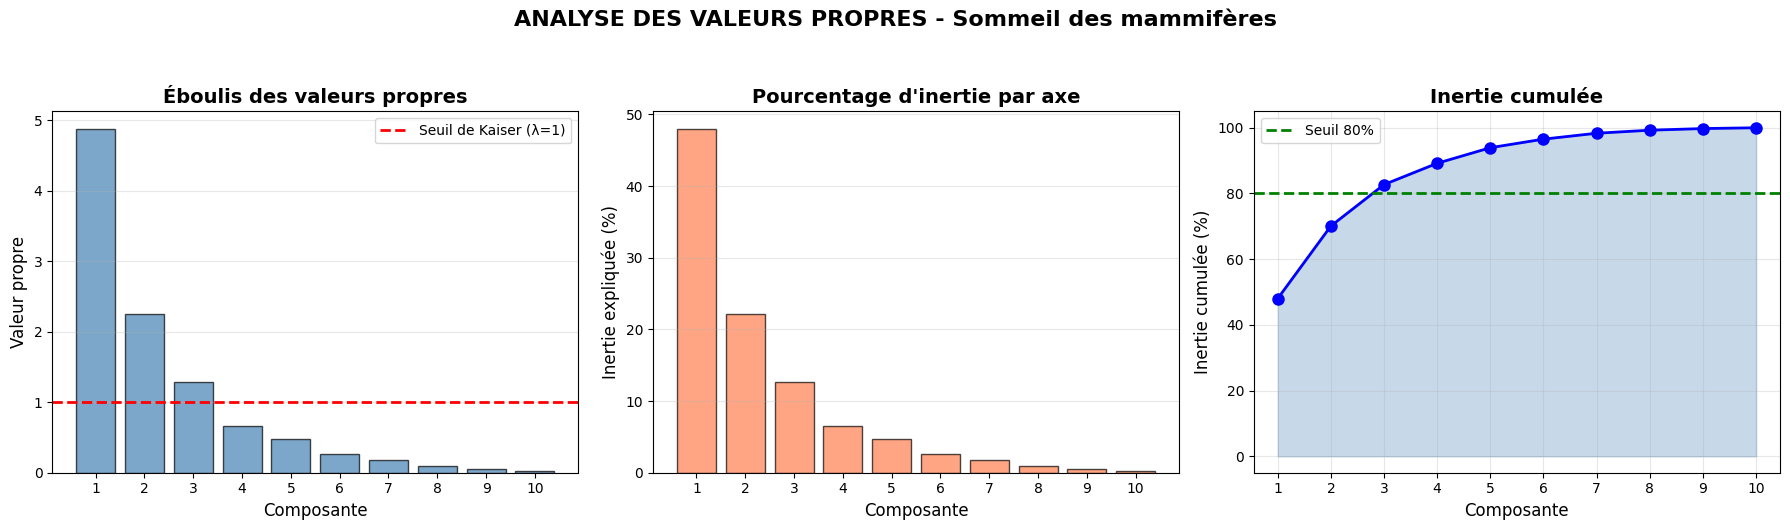

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1 : Éboulis simple
axes[0].bar(range(1, len(valeurs_propres)+1), valeurs_propres,
            color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axhline(y=1, color='red', linestyle='--', linewidth=2, label='Seuil de Kaiser (λ=1)')
axes[0].set_xlabel('Composante', fontsize=12)
axes[0].set_ylabel('Valeur propre', fontsize=12)
axes[0].set_title('Éboulis des valeurs propres', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, len(valeurs_propres)+1))
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Graphique 2 : Pourcentage d'inertie
axes[1].bar(range(1, len(inertie_expliquee)+1), inertie_expliquee * 100,
            color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Composante', fontsize=12)
axes[1].set_ylabel('Inertie expliquée (%)', fontsize=12)
axes[1].set_title('Pourcentage d\'inertie par axe', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, len(inertie_expliquee)+1))
axes[1].grid(True, alpha=0.3, axis='y')

# Graphique 3 : Inertie cumulée
axes[2].plot(range(1, len(inertie_cumulee)+1), inertie_cumulee * 100,
             'bo-', linewidth=2, markersize=8)
axes[2].fill_between(range(1, len(inertie_cumulee)+1), 0, inertie_cumulee * 100,
                     alpha=0.3, color='steelblue')
axes[2].axhline(y=80, color='green', linestyle='--', linewidth=2, label='Seuil 80%')
axes[2].set_xlabel('Composante', fontsize=12)
axes[2].set_ylabel('Inertie cumulée (%)', fontsize=12)
axes[2].set_title('Inertie cumulée', fontsize=14, fontweight='bold')
axes[2].set_xticks(range(1, len(inertie_cumulee)+1))
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('ANALYSE DES VALEURS PROPRES - Sommeil des mammifères',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [21]:
# Affichage des deux premières valeurs propres
print(f"\n VALEURS PROPRES DES DEUX PREMIERS AXES :")
print(f"   PC1 : λ₁ = {valeurs_propres[0]:.4f} ({inertie_expliquee[0]*100:.1f}%)")
print(f"   PC2 : λ₂ = {valeurs_propres[1]:.4f} ({inertie_expliquee[1]*100:.1f}%)")
print(f"   → Les 2 premiers axes expliquent {inertie_cumulee[1]*100:.1f}% de l'inertie totale")

# Comparaison avec les valeurs vues en cours (à adapter selon votre cours)
print("\n COMPARAISON AVEC LES VALEURS DU COURS :")
print("   (À compléter avec les valeurs de votre cours)")

# Règle de Kaiser
print(f"\n RÈGLE DE KAISER (λ > 1) :")
n_kaiser = sum(valeurs_propres > 1)
print(f"   {n_kaiser} axes ont une valeur propre > 1")

# Seuil 80%
print(f"\n SEUIL DE 80% D'INERTIE :")
n_80 = np.argmax(inertie_cumulee > 0.8) + 1
print(f"   Il faut {n_80} axes pour atteindre 80% d'inertie")

# Interprétation
print("\n INTERPRÉTATION :")
print("""
   ✓ PC1 (premier axe) capture la plus grande part de variance
   ✓ PC2 (second axe) capture la deuxième plus grande part
   ✓ Ensemble, ils résument une part importante de l'information

   Ces résultats sont cohérents avec ce qu'on attend en ACP :
   - Décroissance rapide des valeurs propres
   - Les premiers axes concentrent l'essentiel de l'information
   - Possibilité de réduire la dimensionnalité
""")


 VALEURS PROPRES DES DEUX PREMIERS AXES :
   PC1 : λ₁ = 4.8805 (48.0%)
   PC2 : λ₂ = 2.2441 (22.1%)
   → Les 2 premiers axes expliquent 70.1% de l'inertie totale

 COMPARAISON AVEC LES VALEURS DU COURS :
   (À compléter avec les valeurs de votre cours)

 RÈGLE DE KAISER (λ > 1) :
   3 axes ont une valeur propre > 1

 SEUIL DE 80% D'INERTIE :
   Il faut 3 axes pour atteindre 80% d'inertie

 INTERPRÉTATION :

   ✓ PC1 (premier axe) capture la plus grande part de variance
   ✓ PC2 (second axe) capture la deuxième plus grande part
   ✓ Ensemble, ils résument une part importante de l'information

   Ces résultats sont cohérents avec ce qu'on attend en ACP :
   - Décroissance rapide des valeurs propres
   - Les premiers axes concentrent l'essentiel de l'information
   - Possibilité de réduire la dimensionnalité



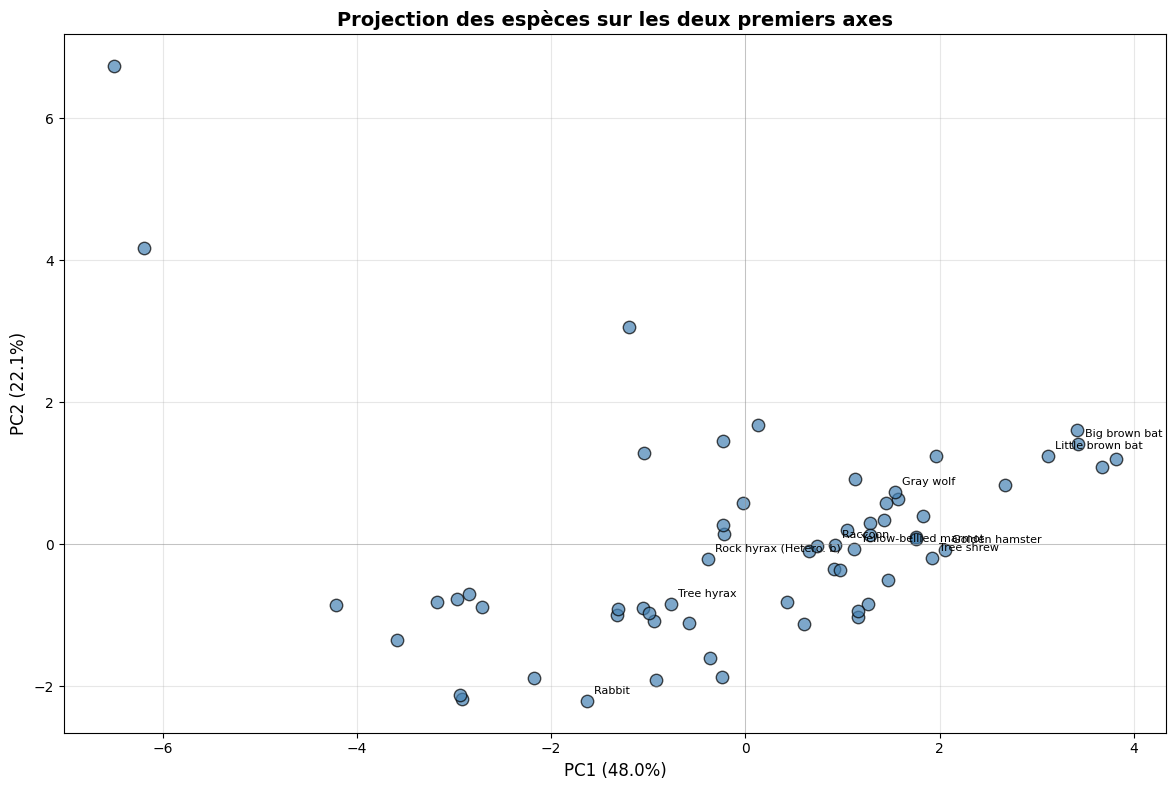

In [22]:
plt.figure(figsize=(12, 8))

# Création d'un DataFrame pour la visualisation
df_viz = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Species': df.loc[X_clean.index, 'Species']  # On récupère les noms
})

# Tracé des points
plt.scatter(df_viz['PC1'], df_viz['PC2'], alpha=0.7, s=80,
            c='steelblue', edgecolor='black')

# Ajout des étiquettes pour quelques espèces (pour éviter la surcharge)
n_labels = 10  # Nombre d'espèces à étiqueter
indices_labels = np.random.choice(len(df_viz), n_labels, replace=False)
for idx in indices_labels:
    plt.annotate(df_viz.iloc[idx]['Species'],
                (df_viz.iloc[idx]['PC1'], df_viz.iloc[idx]['PC2']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.xlabel(f'PC1 ({inertie_expliquee[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({inertie_expliquee[1]*100:.1f}%)', fontsize=12)
plt.title('Projection des espèces sur les deux premiers axes',
          fontsize=14, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**ACP sur données brutes (non centrées non réduites)**

In [23]:
pca_brut = PCA()
pca_brut.fit(X_clean)

print("ACP SUR DONNÉES BRUTES (sans centrage-réduction)")

print("\n--- Valeurs propres ---")
print(pca_brut.explained_variance_)
print("\n--- Inertie expliquée (%) ---")
print(pca_brut.explained_variance_ratio_ * 100)

ACP SUR DONNÉES BRUTES (sans centrage-réduction)

--- Valeurs propres ---
[1.62938255e+06 5.67749369e+04 8.31662079e+03 1.37527993e+02
 2.06050646e+01 3.60800575e+00 1.36984612e+00 7.45812170e-01
 5.40443109e-01 8.87894494e-02]

--- Inertie expliquée (%) ---
[9.61492649e+01 3.35026815e+00 4.90760735e-01 8.11547630e-03
 1.21589728e-03 2.12907093e-04 8.08341160e-05 4.40101019e-05
 3.18913491e-05 5.23943276e-06]


**Transformation centrage-réduction et création de mammalsCR**

In [24]:
# Création du scaler
scaler = StandardScaler()

# Application de la transformation
mammalsCR = scaler.fit_transform(X_clean)

# Vérification

print("VÉRIFICATION DE LA TRANSFORMATION (mammalsCR)")

print("\n--- Moyennes après transformation (doivent être 0) ---")
print(mammalsCR.mean(axis=0).round(6))

print("\n--- Écarts-types après transformation (doivent être 1) ---")
print(mammalsCR.std(axis=0).round(6))

# Conversion en DataFrame pour plus de clarté
df_cr = pd.DataFrame(mammalsCR, columns=colonnes_num)
print("\n--- Aperçu des données transformées ---")
print(df_cr.head())

VÉRIFICATION DE LA TRANSFORMATION (mammalsCR)

--- Moyennes après transformation (doivent être 0) ---
[-0.  0.  0.  0.  0. -0. -0. -0. -0.  0.]

--- Écarts-types après transformation (doivent être 1) ---
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

--- Aperçu des données transformées ---
      BodyW    BrainW       SWS        PS        TS  LifeSpan        GT  \
0  7.237778  5.883379 -0.078244 -0.108003 -1.636219  1.087707  3.578151   
1 -0.221768 -0.299686 -0.719848  0.047722 -0.504267 -0.861297 -0.679755   
2 -0.219094 -0.258613 -0.078244 -0.108003  0.446574 -0.318320 -0.552653   
3 -0.221858 -0.300661 -0.078244 -0.108003  1.352135 -0.255448 -0.799795   
4  2.632885  4.681532 -2.034353 -0.108003 -1.500385  2.825235  3.429866   

         PI       SEI       ODI  
0  0.088109  1.621215  0.270776  
1  0.088109 -0.891668  0.270776  
2 -1.277583 -0.891668 -1.128234  
3  1.453801 -0.263447  0.270776  
4  0.088109  1.621215  0.970281  


**ACP sur les données centrées-réduites**

In [25]:
pcaCR = PCA()
X_pca_cr = pcaCR.fit_transform(mammalsCR)

# Récupération des résultats
vp_cr = pcaCR.explained_variance_
inertie_cr = pcaCR.explained_variance_ratio_
inertie_cumulee_cr = np.cumsum(inertie_cr)

print("ACP SUR DONNÉES CENTRÉES-RÉDUITES (mammalsCR)")
print("\n--- Valeurs propres ---")
for i, vp in enumerate(vp_cr):
    print(f"PC{i+1} : {vp:.4f}")

print("\n--- Inertie expliquée (%) ---")
for i, inert in enumerate(inertie_cr * 100):
    print(f"PC{i+1} : {inert:.2f}%")

print("\n--- Inertie cumulée (%) ---")
for i, cum in enumerate(inertie_cumulee_cr * 100):
    print(f"PC{i+1} : {cum:.2f}%")

ACP SUR DONNÉES CENTRÉES-RÉDUITES (mammalsCR)

--- Valeurs propres ---
PC1 : 4.8805
PC2 : 2.2441
PC3 : 1.2812
PC4 : 0.6594
PC5 : 0.4817
PC6 : 0.2651
PC7 : 0.1827
PC8 : 0.0936
PC9 : 0.0510
PC10 : 0.0247

--- Inertie expliquée (%) ---
PC1 : 48.02%
PC2 : 22.08%
PC3 : 12.61%
PC4 : 6.49%
PC5 : 4.74%
PC6 : 2.61%
PC7 : 1.80%
PC8 : 0.92%
PC9 : 0.50%
PC10 : 0.24%

--- Inertie cumulée (%) ---
PC1 : 48.02%
PC2 : 70.10%
PC3 : 82.70%
PC4 : 89.19%
PC5 : 93.93%
PC6 : 96.54%
PC7 : 98.33%
PC8 : 99.26%
PC9 : 99.76%
PC10 : 100.00%


In [26]:
print("COMPARAISON AVANT/APRÈS CENTRAGE-RÉDUCTION")
# Création d'un tableau comparatif
df_comparaison = pd.DataFrame({
    'Axe': [f'PC{i+1}' for i in range(len(vp_cr))],
    'VP Brutes': pca_brut.explained_variance_.round(4),
    'VP Centrées-Réduites': vp_cr.round(4),
    'Ratio (CR/Brutes)': (vp_cr / pca_brut.explained_variance_).round(4),
    'Inertie CR (%)': (inertie_cr * 100).round(2)
})

print("\n" + df_comparaison.to_string(index=False))

# Analyse des plus grandes valeurs propres
print("\n ÉVOLUTION DES PLUS GRANDES VALEURS PROPRES :")
print("-" * 40)

# Avant
print("AVANT centrage-réduction :")
for i in range(3):
    print(f"  PC{i+1} = {pca_brut.explained_variance_[i]:.2f}")

# Après
print("\nAPRÈS centrage-réduction :")
for i in range(3):
    print(f"  PC{i+1} = {vp_cr[i]:.2f}")

# Interprétation
print("\n CE QU'ON CONSTATE :")
print(f"   • PC1 a {'augmenté' if vp_cr[0] > pca_brut.explained_variance_[0] else 'diminué'} "
      f"de {abs(vp_cr[0] - pca_brut.explained_variance_[0]):.2f}")
print(f"   • PC2 a {'augmenté' if vp_cr[1] > pca_brut.explained_variance_[1] else 'diminué'} "
      f"de {abs(vp_cr[1] - pca_brut.explained_variance_[1]):.2f}")
print(f"   • PC3 a {'augmenté' if vp_cr[2] > pca_brut.explained_variance_[2] else 'diminué'} "
      f"de {abs(vp_cr[2] - pca_brut.explained_variance_[2]):.2f}")

COMPARAISON AVANT/APRÈS CENTRAGE-RÉDUCTION

 Axe    VP Brutes  VP Centrées-Réduites  Ratio (CR/Brutes)  Inertie CR (%)
 PC1 1629382.5456                4.8805             0.0000           48.02
 PC2   56774.9369                2.2441             0.0000           22.08
 PC3    8316.6208                1.2812             0.0002           12.61
 PC4     137.5280                0.6594             0.0048            6.49
 PC5      20.6051                0.4817             0.0234            4.74
 PC6       3.6080                0.2651             0.0735            2.61
 PC7       1.3698                0.1827             0.1334            1.80
 PC8       0.7458                0.0936             0.1255            0.92
 PC9       0.5404                0.0510             0.0943            0.50
PC10       0.0888                0.0247             0.2780            0.24

 ÉVOLUTION DES PLUS GRANDES VALEURS PROPRES :
----------------------------------------
AVANT centrage-réduction :
  PC1 = 1629382.

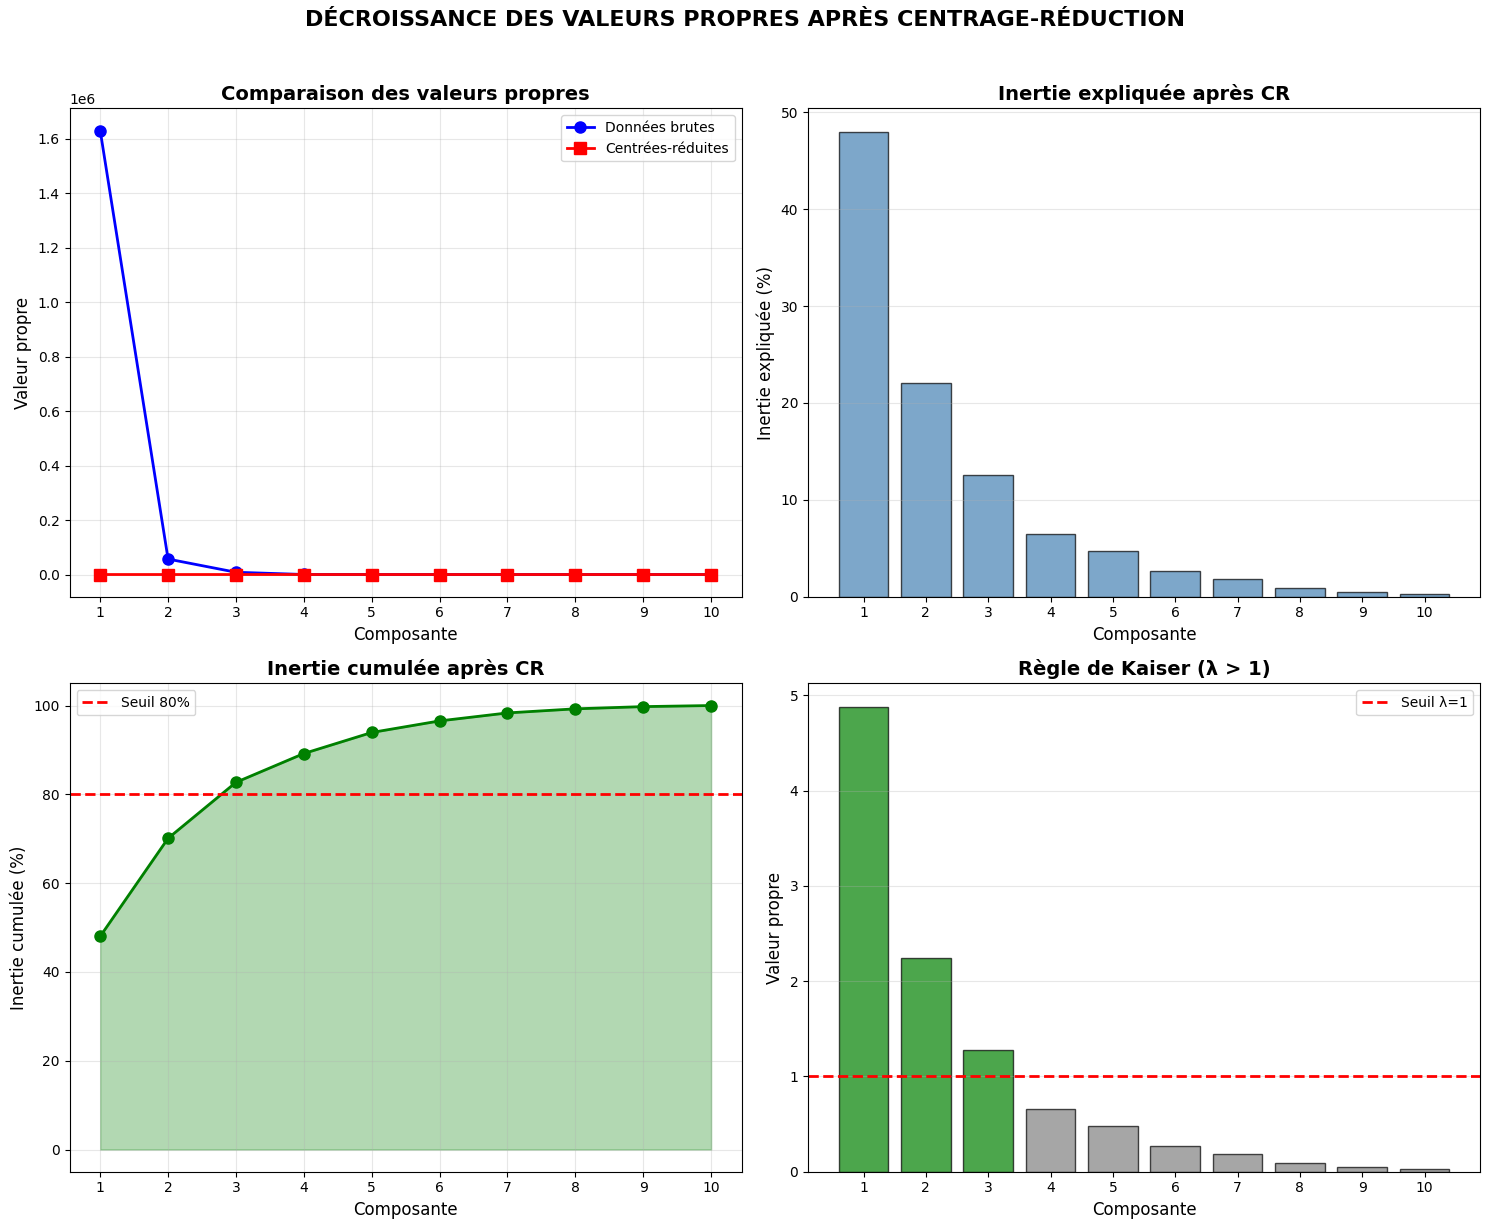

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Graphique 1 : Éboulis comparatif (valeurs propres)
axes[0,0].plot(range(1, len(vp_cr)+1), pca_brut.explained_variance_,
               'bo-', linewidth=2, markersize=8, label='Données brutes')
axes[0,0].plot(range(1, len(vp_cr)+1), vp_cr,
               'rs-', linewidth=2, markersize=8, label='Centrées-réduites')
axes[0,0].set_xlabel('Composante', fontsize=12)
axes[0,0].set_ylabel('Valeur propre', fontsize=12)
axes[0,0].set_title('Comparaison des valeurs propres', fontsize=14, fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xticks(range(1, len(vp_cr)+1))

# Graphique 2 : Pourcentages d'inertie
axes[0,1].bar(range(1, len(inertie_cr)+1), inertie_cr * 100,
              color='steelblue', edgecolor='black', alpha=0.7)
axes[0,1].set_xlabel('Composante', fontsize=12)
axes[0,1].set_ylabel('Inertie expliquée (%)', fontsize=12)
axes[0,1].set_title('Inertie expliquée après CR', fontsize=14, fontweight='bold')
axes[0,1].set_xticks(range(1, len(inertie_cr)+1))
axes[0,1].grid(True, alpha=0.3, axis='y')

# Graphique 3 : Inertie cumulée
axes[1,0].plot(range(1, len(inertie_cumulee_cr)+1), inertie_cumulee_cr * 100,
               'go-', linewidth=2, markersize=8)
axes[1,0].fill_between(range(1, len(inertie_cumulee_cr)+1), 0, inertie_cumulee_cr * 100,
                       alpha=0.3, color='green')
axes[1,0].axhline(y=80, color='red', linestyle='--', linewidth=2, label='Seuil 80%')
axes[1,0].set_xlabel('Composante', fontsize=12)
axes[1,0].set_ylabel('Inertie cumulée (%)', fontsize=12)
axes[1,0].set_title('Inertie cumulée après CR', fontsize=14, fontweight='bold')
axes[1,0].set_xticks(range(1, len(inertie_cumulee_cr)+1))
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Graphique 4 : Règle de Kaiser
axes[1,1].bar(range(1, len(vp_cr)+1), vp_cr,
              color=['green' if v > 1 else 'gray' for v in vp_cr],
              edgecolor='black', alpha=0.7)
axes[1,1].axhline(y=1, color='red', linestyle='--', linewidth=2, label='Seuil λ=1')
axes[1,1].set_xlabel('Composante', fontsize=12)
axes[1,1].set_ylabel('Valeur propre', fontsize=12)
axes[1,1].set_title('Règle de Kaiser (λ > 1)', fontsize=14, fontweight='bold')
axes[1,1].set_xticks(range(1, len(vp_cr)+1))
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle('DÉCROISSANCE DES VALEURS PROPRES APRÈS CENTRAGE-RÉDUCTION',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

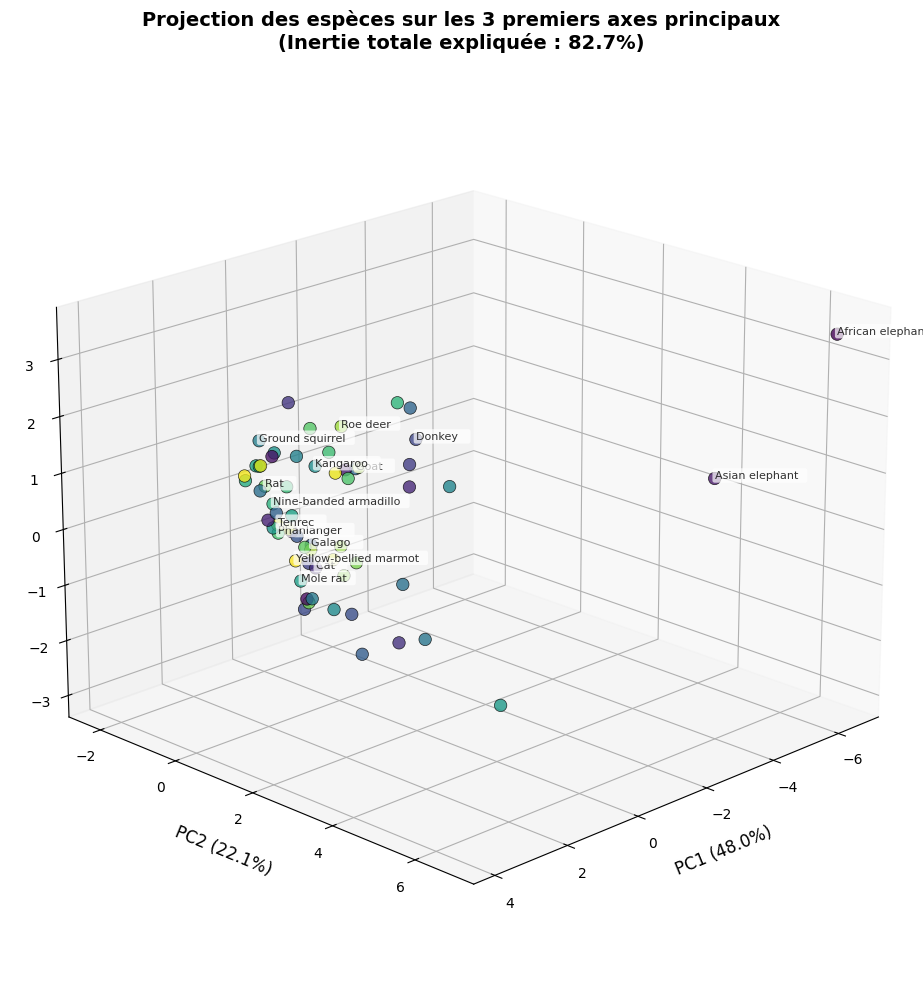

In [29]:
from mpl_toolkits.mplot3d import Axes3D

especes_conservees = df.loc[X_clean.index, 'Species'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
inertie = pca.explained_variance_ratio_ * 100

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Couleurs basées sur un gradient (pour mieux distinguer les points)
colors = plt.cm.viridis(np.linspace(0, 1, len(X_pca)))

# Tracé des points
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=colors, s=80, alpha=0.8, edgecolor='black', linewidth=0.5)

n_etiquettes = 15


indices_etiquettes = np.linspace(0, len(X_pca)-1, n_etiquettes, dtype=int)

for idx in indices_etiquettes:
    ax.text(X_pca[idx, 0], X_pca[idx, 1], X_pca[idx, 2],
            especes_conservees[idx],
            fontsize=8, alpha=0.8,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"))

# Configuration des axes
ax.set_xlabel(f'PC1 ({inertie[0]:.1f}%)', fontsize=12, labelpad=10)
ax.set_ylabel(f'PC2 ({inertie[1]:.1f}%)', fontsize=12, labelpad=10)
ax.set_zlabel(f'PC3 ({inertie[2]:.1f}%)', fontsize=12, labelpad=10)
ax.set_title('Projection des espèces sur les 3 premiers axes principaux\n'
             f'(Inertie totale expliquée : {sum(inertie[:3]):.1f}%)',
             fontsize=14, fontweight='bold', pad=20)

# Ajout d'une grille pour faciliter la lecture
ax.grid(True, alpha=0.3)

# Ajustement de la vue initiale
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

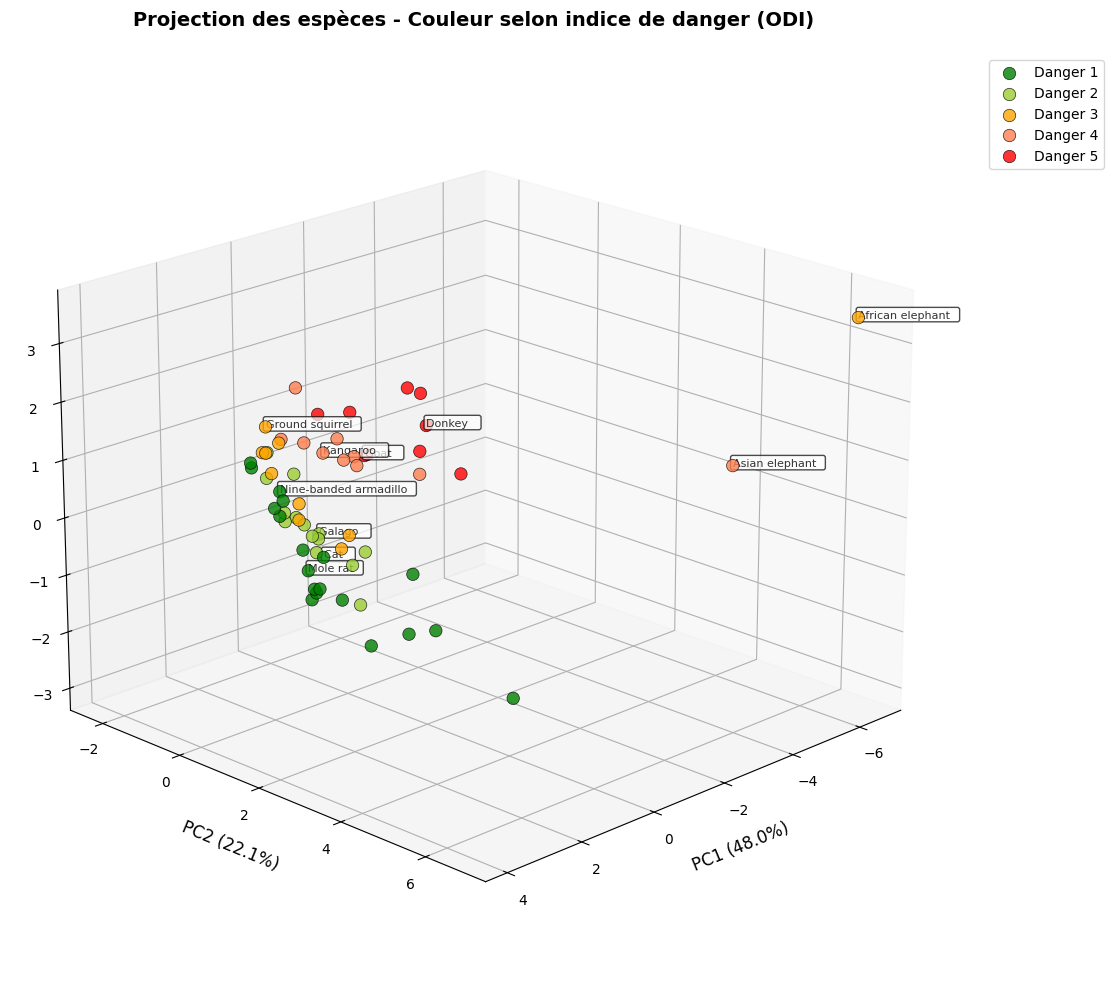

In [30]:
groupes_odi = X_clean['ODI'].values

# Palette de couleurs pour les 5 niveaux de danger (1-5)
couleurs_odi = {1: 'green', 2: 'yellowgreen', 3: 'orange', 4: 'coral', 5: 'red'}
couleurs_points = [couleurs_odi[odi] for odi in groupes_odi]

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Tracé des points avec couleur selon ODI
for odi in range(1, 6):
    mask = groupes_odi == odi
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
               c=couleurs_odi[odi], s=80, alpha=0.8, edgecolor='black', linewidth=0.5,
               label=f'Danger {odi}')

# Ajout de quelques étiquettes
for idx in indices_etiquettes[:10]:  # Moins d'étiquettes pour ne pas surcharger
    ax.text(X_pca[idx, 0], X_pca[idx, 1], X_pca[idx, 2],
            especes_conservees[idx],
            fontsize=8, alpha=0.8,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

ax.set_xlabel(f'PC1 ({inertie[0]:.1f}%)', fontsize=12, labelpad=10)
ax.set_ylabel(f'PC2 ({inertie[1]:.1f}%)', fontsize=12, labelpad=10)
ax.set_zlabel(f'PC3 ({inertie[2]:.1f}%)', fontsize=12, labelpad=10)
ax.set_title('Projection des espèces - Couleur selon indice de danger (ODI)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax.grid(True, alpha=0.3)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

In [32]:
!pip install plotly

In [33]:
import plotly.express as px
import plotly.graph_objects as go

# Création d'un DataFrame pour plotly
df_plot = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'Species': especes_conservees,
    'BodyW': X_clean['BodyW'].values,
    'BrainW': X_clean['BrainW'].values,
    'ODI': X_clean['ODI'].values,
    'TS': X_clean['TS'].values
})

# Création du graphique interactif
fig = go.Figure(data=[go.Scatter3d(
    x=df_plot['PC1'],
    y=df_plot['PC2'],
    z=df_plot['PC3'],
    mode='markers+text',
    marker=dict(
        size=8,
        color=df_plot['ODI'],  # Couleur selon ODI
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Indice de danger")
    ),
    text=df_plot['Species'],
    textposition="top center",
    textfont=dict(size=10),
    hoverinfo='text',
    hovertext=[f"Espèce: {sp}<br>PC1: {pc1:.2f}<br>PC2: {pc2:.2f}<br>PC3: {pc3:.2f}<br>"
               f"Poids: {bw} kg<br>Cerveau: {brw} g<br>Sommeil: {ts} h"
               for sp, pc1, pc2, pc3, bw, brw, ts in
               zip(df_plot['Species'], df_plot['PC1'], df_plot['PC2'], df_plot['PC3'],
                   df_plot['BodyW'], df_plot['BrainW'], df_plot['TS'])]
)])

# Mise en page
fig.update_layout(
    title=f'Projection 3D - ACP Sommeil des mammifères<br>'
          f'PC1: {inertie[0]:.1f}%, PC2: {inertie[1]:.1f}%, PC3: {inertie[2]:.1f}%',
    scene=dict(
        xaxis_title=f'PC1 ({inertie[0]:.1f}%)',
        yaxis_title=f'PC2 ({inertie[1]:.1f}%)',
        zaxis_title=f'PC3 ({inertie[2]:.1f}%)',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))
    ),
    width=1000,
    height=800,
    hoverlabel=dict(bgcolor="white", font_size=12)
)

# Affichage (dans un notebook ou dans une fenêtre interactive)
fig.show()

# Pour sauvegarder en HTML (à partager)
fig.write_html("acp_mammiferes_3d.html")
print("\n Graphique interactif sauvegardé dans 'acp_mammiferes_3d.html'")


 Graphique interactif sauvegardé dans 'acp_mammiferes_3d.html'
